# 10강 Logistic Regression 
**참고 교재: Bishop (2006) Chapter 4 Linear Models for Classification**


10강에서는 로지스틱 회귀(Logistic Regression)와 관련하여 다음의 내용들을 살펴본다.  
- **Generative Approach**와 **Discriminative Approach**를 간단히 비교  
- 로지스틱 회귀 모델의 수학적 유도 (Log-odds, Maximum Likelihood, Gradient 등)  
- 로지스틱 회귀의 **Basis expansion**  
- 예제 데이터를 사용한 로지스틱 회귀 뉴턴 방법 구현 

## 1. 로지스틱 회귀 소개

### 1.1. 분류 문제와 로지스틱 회귀

이진 분류(binary classification)는 입력 벡터 $\mathbf{x}$가 주어졌을 때, 클래스 $ C_1 $ 혹은 클래스 $ C_0 $에 속할 확률을 예측하는 문제이다.

로지스틱 회귀는 **시그모이드(Sigmoid)** 함수를 통해
$$
p(C_1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + w_0)
$$
형태로 확률을 계산하는 **Discriminative model**의 대표적 예이다.

### 1.2. 생성형 접근방식(Generative Approach) vs 식별형 접근방식(Discriminative Approach)

- **생성형 접근 (Generative Approach)**  
  - 데이터가 생성되는 과정 자체를 모델링
  - $ p(x,y) $를 직접 추정, $ p(y\mid x) = \frac{p(x,y)}{p(x)}$ 이용하여 분류/예측

  
- **식별형 접근 (Discriminative Approach)**  
  - 주어진 입력 $x$가 어떤 레이블 $y$로 식별되는지를 모델링
  - $ p(y \mid x) $ 또는 결정 경계(Decision boundary)를 직접 학습하여 분류/예측 


## 2. Generative Approach에서의 유도

$$
p(x \mid C_1) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_1, \Sigma), \quad
p(x \mid C_0) = \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_0, \Sigma)
$$
위와 같이 **같은 공분산 행렬** $\Sigma$를 사용하고, **평균만 다른** 두 개의 다변량 정규분포를 가정해보자. 두 클래스의 사전확률을 각각 $p(C_1), p(C_0)$라 할 때,

$$
p(C_1 \mid \mathbf{x}) 
= \frac{ p(\mathbf{x} \mid C_1)\,p(C_1) }{ p(\mathbf{x} \mid C_1)\,p(C_1) + p(\mathbf{x} \mid C_0)\,p(C_0) }
= \frac{1}{1 + \frac{p(\mathbf{x} \mid C_0)\,p(C_0)}{p(\mathbf{x} \mid C_1)\,p(C_1)} }
$$

로그를 취하거나, 가우시안 형태를 풀어서 쓰면 다음과 같은 지수함수 형태가 된다.

$$
p(C_1 \mid \mathbf{x}) 
= \frac{1}{1 + \exp\left(-(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_0)^T \Sigma^{-1} \mathbf{x} + \text{const.}\right)}.
$$

즉, **결과적으로 시그모이드 형태**로 나타남을 확인할 수 있다. 

## 3. Discriminative Approach (Logistic Regression)

### 3.1. 로지스틱 시그모이드(logistic sigmoid) 함수

로지스틱 회귀에서 사용하는 로지스틱 시그모이드 함수 $\sigma(a)$는
$$
\sigma(a) = \frac{1}{1 + e^{-a}}
$$
로 정의되며, 다음과 같은 성질을 갖는다.

1. $\sigma(-a) = 1 - \sigma(a)$
2. $\sigma'(a) = \sigma(a)\,\sigma(-a) = \sigma(a)\,\bigl(1 - \sigma(a)\bigr)$


### 3.2. 모델 식 및 로짓(logit, log-odds)

시그모이드 함수 $\sigma(a)$의 역함수는 로짓(logit)함수로 다음과 같다.

$$
a= \log \left( \frac{\sigma}{1-\sigma} \right)
$$

로지스틱 회귀에서는
$$
p(C_1 \mid \mathbf{x}) = \frac{1}{1 + \exp(-\mathbf{w}^T \mathbf{x})}
= \sigma(\mathbf{w}^T \mathbf{x}).
$$

클래스 $C_0$의 확률은
  $$
  p(C_0 \mid \mathbf{x}) = 1 - p(C_1 \mid \mathbf{x}) = \frac{\exp(-\mathbf{w}^T \mathbf{x})}{1 + \exp(-\mathbf{w}^T \mathbf{x})}.
  $$

### <"분류 문제의 접근 방법" 마지막 슬라이드에 대한 강의 내용 정정>

오즈(odds)와 로그오즈(log-odds)는 다음과 같이 정의된다(강의에서는 오즈비와 로그오즈라고 설명함).

- **오즈:**
  $$
  \frac{p(C_1 \mid \mathbf{x})}{1 - p(C_1 \mid \mathbf{x})} = \exp(\mathbf{w}^T \mathbf{x}).
  $$
  

- **로그오즈:**
$$
\log \left( \frac{p(C_1 \mid \mathbf{x})}{1 - p(C_1 \mid \mathbf{x})} \right)
  = \mathbf{w}^T \mathbf{x}.
$$

**<오즈비 관련 추가 설명>**

위의 오즈는 관점에 따라 오즈비로 해석될 수 있다.

**1. 기준 오즈(baseline odds)로부터의 증가/감소를 표현하기 위한 오즈비 해석**

$\exp(\mathbf{w}^T \mathbf{x})$ 값은 모든 feature 값들이 0이었을 때의 기준 오즈( =$\exp(w_0)$ )에서 얼마나 올라갔는지 혹은 내려갔는지를 나타내는 오즈비로 해석할 수 있다.


**2. 개별 feature에 대한 오즈비 해석**

feature 를 $x_1, x_2, ..., x_{M-1}$ 이렇게 세부적으로 나누어서 볼 때, 각 파라미터들에 대한 개별적인 오즈비로 해석하는 것이다.

구체적으로, 다른 feature 들을 고정한 상태에서 특정 feature 가 1만큼 증가할 때 오즈가 얼마나 변하는지를 오즈비로 표현하는 것이다.

예를 들어, 첫 번째 feature 인 $x_1$ 에 대한 영향력을 표현하고 싶다면,  파라미터(회귀계수) $w_1$ 의 값을 이용하는데,

이때, $\exp(w_1)$ 를 오즈비로 해석한다. 다시 말해서 "$x_1$ 이 1 증가할 때 오즈가 $\exp(w_1)$ 배 된다"는 의미이다.

수식으로 표현하면,


- **로그 오즈:**
$$
\log \left(\frac{p}{1 - p}\right)
= w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_{M-1} x_{M-1}.
$$


- **오즈:**
$$
\frac{p}{1 - p}
= \exp \left( w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_{M-1} x_{M-1}\right).
$$

위 식에 의하면, 오즈(좌측 항)는 $x_1$이 1만큼 증가하면(다른 변수들은 고정), 이전보다 오즈가 $\exp(w_1)$배 증가하는 것을 볼 수 있다. 즉, $x_1$ feature에 대한 오즈비(OR)는 $\exp(w_1)$이다.


- **오즈비:**

$$
\frac{p^{\prime}/(1 - p^{\prime})}{p/(1-p)}
= \frac{\exp \left( w_0 + w_1 (x_1 + 1) + w_2 x_2 + \cdots + w_{M-1} x_{M-1}\right)}{\exp \left( w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_{M-1} x_{M-1}\right)} = \exp(w_1)
$$

- **로그 오즈비:** 위 식에서 양변에 로그를 취함

$$
\log \left( \frac{p^{\prime}/(1 - p^{\prime})}{p/(1-p)} \right) = w_1
$$



  
  

## 4. Maximum Likelihood Estimation

### 4.1. Likelihood와 Cross-Entropy

훈련 데이터 $\{(\mathbf{x}_n, t_n)\}$ ($t_n \in \{0,1\}$)에 대해 로지스틱 회귀의 파라미터 $\mathbf{w}$를 학습하려면, Log-Likelihood(우도)를 최대화한다. 각 샘플에 대해
$$
p(t_n \mid \mathbf{x}_n) = \sigma(\mathbf{w}^T \mathbf{x}_n)^{t_n} \bigl[1 - \sigma(\mathbf{w}^T \mathbf{x}_n)\bigr]^{1 - t_n}.
$$

우도의 로그를 취하면 **Cross-Entropy** 형태가 된다.

$$
\ell(\mathbf{w}) = \sum_{n=1}^N \Bigl[
t_n \log \sigma(\mathbf{w}^T \mathbf{x}_n) + (1 - t_n)\log \bigl(1 - \sigma(\mathbf{w}^T \mathbf{x}_n)\bigr)
\Bigr].
$$

이를 최대화하는 것은 곧 로지스틱 손실(Logistic loss, Binary cross-entropy)를 최소화하는 것과 동일하다.

### 4.2. Gradient (경사)

위 우도 함수를 최대로 하는 $\mathbf{w}$를 찾기 위해서는 경사를 0으로 만드는 방식(또는 경사하강법)을 사용한다. 

$$
\nabla \ell(\mathbf{w}) = \sum_{n=1}^N \Bigl[ t_n - \sigma(\mathbf{w}^T \mathbf{x}_n)\Bigr]\mathbf{x}_n.
$$

이를 이용해 경사상승(gradient ascent) 혹은 경사하강(손실 관점) 방법으로 업데이트할 수 있다.

### 참고: Gradient 유도 과정

- $\mathbf{w}^T \mathbf{x}_n \equiv a_n$, $\sigma(a_n) \equiv y_n$라고 하면,  
  $$\ell(\mathbf{w}) = \sum_{n=1}^N \bigl[t_n \log y_n + (1 - t_n)\log(1 - y_n)\bigr].$$

$\ell(\mathbf{w})$를 $\mathbf{w}$에 대해 미분하기 위해 각 항을 살펴보자.

1. 좌측 항 $\nabla_{\mathbf{w}} (t_n \log y_n)$  부분
   - $ \log y_n $을 $\mathbf{w}$로 미분하면,  
     $$
     \nabla_{\mathbf{w}} \log y_n 
     = \frac{1}{y_n} \,\nabla_{\mathbf{w}} (y_n)
     = \frac{1}{y_n} \times y_n(1 - y_n)\,\mathbf{x}_n
     = (1-y_n)\,\mathbf{x}_n.
     $$  
   - 따라서
$$ \nabla_{\mathbf{w}} (t_n \log y_n) = t_n (1-y_n)\,\mathbf{x}_n .$$

2. 우측 항 $\nabla_{\mathbf{w}} \bigl((1 - t_n)\log (1 - y_n)\bigr)$  부분
   - $ \log (1-y_n) $을 $\mathbf{w}$로 미분하면,  
     $$
     \nabla_{\mathbf{w}} \log (1-y_n) 
     = \frac{-\nabla_{\mathbf{w}} (y_n)}{1-y_n}
     = -\,y_n\,\mathbf{x}_n.
     $$  
   - 따라서
$$ \nabla_{\mathbf{w}} ((1 - t_n)\log(1 - y_n)) = (1 - t_n)(-y_n)\,\mathbf{x}_n .$$

두 항을 합치면,  
$$
\nabla_{\mathbf{w}} \ell(\mathbf{w})
= \sum_{n=1}^N \Bigl[t_n(1-y_n) - (1 - t_n) y_n \Bigr]\mathbf{x}_n
= \sum_{n=1}^N (t_n - y_n)\,\mathbf{x}_n.
$$

결론적으로,

$$
\nabla_{\mathbf{w}} \ell(\mathbf{w}) 
= \sum_{n=1}^N \Bigl[t_n - \sigma(\mathbf{w}^T \mathbf{x}_n)\Bigr]\mathbf{x}_n.
$$



## 5. 로지스틱 회귀 구현 예제

이제 다음의 예제 데이터를 만들어 직접 로지스틱 회귀를 구현해보자.  
- 2차원 입력 $\mathbf{x} = (x_1, x_2)$  
- 두 개의 클래스 $ C_1 $과 $ C_0 $에 대해 무작위로 데이터를 생성  

**목표:**
1) **Cost function**의 감소 과정을 출력  
2) 최종 학습된 $\mathbf{w}$로부터 결정 경계(Decision Boundary)를 시각화 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X.shape = (200, 2) t.shape = (200,)


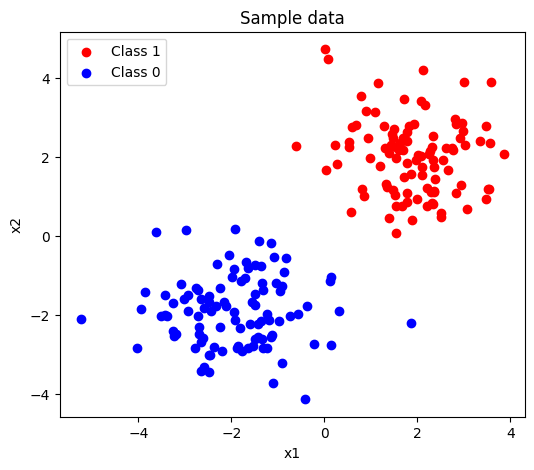

In [2]:
# -----------------------------------------
# 1. 데이터 생성
# -----------------------------------------

# 클래스 1 (label=1) 샘플들: 대략 (2,2) 근방에 모여있게 만든다.
N = 100  # 각 클래스당 샘플 수
x1_class1 = np.random.normal(loc=2.0, scale=1.0, size=N)
x2_class1 = np.random.normal(loc=2.0, scale=1.0, size=N)
X_class1 = np.column_stack((x1_class1, x2_class1))
y_class1 = np.ones(N)

# 클래스 0 (label=0) 샘플들: 대략 (-2,-2) 근방에 모여있게 만든다.
x1_class0 = np.random.normal(loc=-2.0, scale=1.0, size=N)
x2_class0 = np.random.normal(loc=-2.0, scale=1.0, size=N)
X_class0 = np.column_stack((x1_class0, x2_class0))
y_class0 = np.zeros(N)

# 전체 데이터 합치기
X = np.vstack((X_class1, X_class0))  # shape = (2N, 2)
t = np.concatenate((y_class1, y_class0))  # shape = (2N, )

print("X.shape =", X.shape, "t.shape =", t.shape)

# 시각화
plt.figure(figsize=(6,5))
plt.scatter(X_class1[:,0], X_class1[:,1], color='r', label='Class 1')
plt.scatter(X_class0[:,0], X_class0[:,1], color='b', label='Class 0')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Sample data')
plt.show()


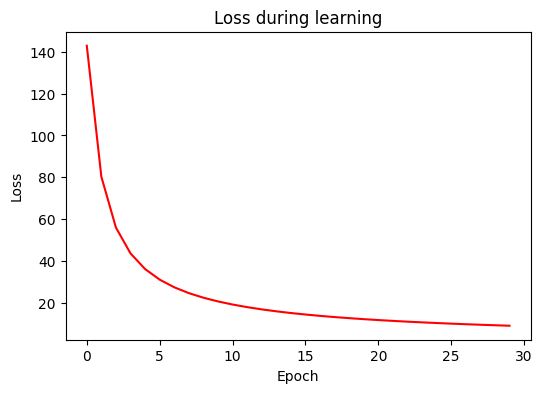

학습 후 파라미터 w = [ 0.96013917  1.03242566 -0.02833284]


In [3]:
# -----------------------------------------
# 2. 시그모이드 함수 구현
# -----------------------------------------
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-a))

# -----------------------------------------
# 3. 로지스틱 회귀 (경사하강법) 구현
# -----------------------------------------

# (1) 파라미터 초기화
#     feature dimension = 2, 따라서 w는 (3,) shape (bias 포함 위해 +1)
w = np.random.randn(3) * 0.01

# (2) 학습을 위해 X에 bias항 추가
#     X.shape = (2N, 2)
#     --> X_with_bias.shape = (2N, 3)  [마지막 col에 1]
X_with_bias = np.hstack([X, np.ones((X.shape[0], 1))])

# (3) 손실함수(이진크로스엔트로피) & 경사 계산 함수
def compute_loss_and_grad(w, Xb, t):
    """
    w: (3,) vector / Xb: (2N, 3) / t: (2N, )
    """
    # z = w^T x
    z = Xb.dot(w)  # shape=(2N,)
    # y = sigmoid(z)
    y = sigmoid(z)  # shape=(2N,)
    
    # (a) loss (cross-entropy)
    #    -\sum [ t_n log y_n + (1 - t_n) log(1 - y_n) ]
    eps = 1e-10
    loss = - np.sum( t*np.log(y+eps) + (1-t)*np.log(1-y+eps) )

    # (b) gradient
    #    \nabla = \sum (y_n - t_n) * x_n
    grad = Xb.T.dot(y - t)  # shape=(3,)
    
    return loss, grad

# (4) 학습 루프
learning_rate = 0.001
n_epochs = 30
loss_history = []

for epoch in range(n_epochs):
    loss, grad = compute_loss_and_grad(w, X_with_bias, t)
    w = w - learning_rate * grad  # 경사하강 업데이트
    loss_history.append(loss)

# 학습 결과 확인
plt.figure(figsize=(6,4))
plt.plot(loss_history, 'r-')
plt.title("Loss during learning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("학습 후 파라미터 w =", w)


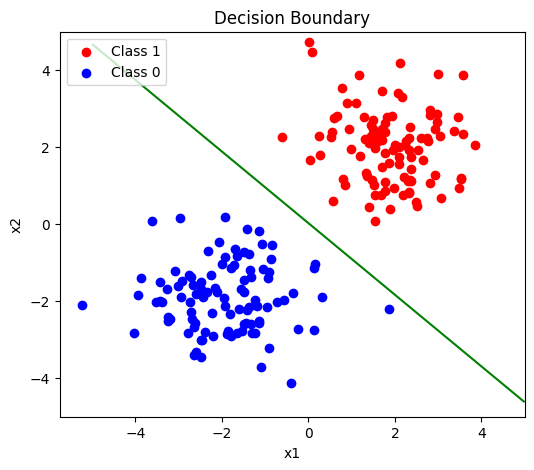

In [4]:
# -----------------------------------------
# 4. Decision Boundary 시각화
# -----------------------------------------
plt.figure(figsize=(6,5))
plt.scatter(X_class1[:,0], X_class1[:,1], color='r', label='Class 1')
plt.scatter(X_class0[:,0], X_class0[:,1], color='b', label='Class 0')

# 결정 경계를 위해 x1, x2 범위에서 그리드 생성
x1_vals = np.linspace(-5, 5, 100)
x2_vals = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# 각 지점에서 로지스틱 회귀 결과 p(C1|x)가 0.5가 되는 선을 찾는다.
# p(C1|x) = sigmoid(w0*x1 + w1*x2 + b) = 0.5
# --> w0*x1 + w1*x2 + b = 0
# --> x2 = -(w0*x1 + b)/w1
# 여기는 meshgrid 전부를 한번에 계산해서 contour 그리자.

Xb_grid = np.c_[X1.ravel(), X2.ravel(), np.ones_like(X1.ravel())]
y = sigmoid(Xb_grid.dot(w))
y = y.reshape(X1.shape)

# contour(등고선)로 p=0.5인 라인만 그려주기
plt.contour(X1, X2, y, levels=[0.5], colors='g')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Decision Boundary')
plt.show()


## 6. 중간 정리: 로지스틱 회귀

1. **Generative vs Discriminative**  
   - 정규분포(또는 다른 분포)를 가정해 $ p(\mathbf{x}\mid C_i) $를 모델링하는 Generative Approach는 데이터 분포 자체를 추정한다.  
   - Logistic Regression은 $ p(C_1\mid \mathbf{x}) $ 자체를 직접 모델링(=결정경계 직접 학습)하는 Discriminative Approach이므로,  
     데이터 분포 자체에 대한 정보는 명시적으로 주지 않지만, 결정경계를 좀 더 직접적으로 학습한다.

2. **Logistic Sigmoid & Log-odds**  
   - $\sigma(a)$가 0~1 범위를 갖는 덕분에 확률로 해석하기 용이하다.  
   - $\log$-odds가 선형식 $\mathbf{w}^T \mathbf{x}$가 된다는 점이 가장 큰 특징이다.

3. **학습**  
   - Negative log-likelihood(또는 Cross-Entropy)를 최소화하는 문제가 된다.  
   - SGD(확률적 경사하강법)나 GD(배치 경사하강법) 등으로 쉽게 최적화 가능.  
   - 오버피팅을 방지하기 위해서는 $L_2$ 정규화(릿지)나 $L_1$ 정규화(라쏘)를 포함시킬 수 있다.


## 7. 로지스틱 회귀: Basis expansion

입력 $\mathbf{x}$가 주어졌을 때, 클래스 $C_1$에 속할 확률을  
$$
y_n = p(C_1 \mid \mathbf{x}_n) = \sigma(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)),
\quad
\text{where}\;\sigma(a) = \frac{1}{1 + e^{-a}}
$$
로 정의해보자. 여기서

- $\boldsymbol{\phi}(\mathbf{x}_n)$은 feature transformation 역할을 하는 기저 함수(basis function)이다.
- $y_n$은 $\mathbf{x}_n$가 주어졌을 때, 클래스 $C_1$일 확률 예측치이다.


### 7.1 우도 함수 (Likelihood function)

훈련 데이터가 
$$
D = \{(\mathbf{x}_n, t_n)\}_{n=1}^N,
\quad t_n \in \{0,1\}
$$
라고 할 때, 로지스틱 모델에서 각 표본 $(\mathbf{x}_n, t_n)$에 대한 조건부 확률은

$$
p(t_n \mid y_n) = y_n^{t_n}(1 - y_n)^{1 - t_n}.
$$

즉, 만약 $t_n = 1$이면 $p(t_n \mid y_n) = y_n$,  
만약 $t_n = 0$이면 $p(t_n \mid y_n) = 1 - y_n$.

따라서 전체 데이터셋에 대한 우도(likelihood)는

$$
\begin{align}
L(\mathbf{w}) &= p(\mathbf{t} \mid \mathbf{w}) \\
&= \prod_{n=1}^N p(t_n \mid y_n) \\
&= \prod_{n=1}^N y_n^{t_n} (1 - y_n)^{1 - t_n},
\end{align}
$$
이 된다.


### 7.2 로그 우도(log-likelihood)

$$
\begin{align}
\ell(\mathbf{w}) 
&= \log L(\mathbf{w}) \\
&= \log \prod_{n=1}^N \Bigl( y_n^{t_n} \,(1 - y_n)^{1 - t_n} \Bigr)\\
&= \sum_{n=1}^N \Bigl( t_n \log y_n + (1 - t_n)\log(1 - y_n)\Bigr).
\end{align}
$$

여기서 $y_n = \sigma(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n))$.


### 7.3 음의 로그 우도 (Negative log-likelihood)

로그 우도를 **최대화**하는 대신, 이를 음수 부호로 바꾼 negative log-likelihood를 **최소화**하는 문제로 바꿔서 푼다:

$$
\begin{align}
E(\mathbf{w}) 
&= - \log L(\mathbf{w}) \\
&= - \ell(\mathbf{w}) \\
&= - \sum_{n=1}^N \bigl[ t_n \log y_n + (1 - t_n)\log (1 - y_n)\bigr].
\end{align}
$$

크로스 엔트로피 오차(cross-entropy error)로도 불리며, 이진 분류 문제에서 널리 쓰이는 손실 함수이다.


### 7.4 로지스틱 회귀의 학습: 그래디언트 계산

$$
\nabla_{\mathbf{w}} E(\mathbf{w}) 
= - \frac{\partial}{\partial \mathbf{w}} \sum_{n=1}^N \Bigl[ t_n \log y_n + (1 - t_n)\log (1 - y_n)\Bigr].
$$

앞에서처럼 미분하여 전개해 보면,

$$
\nabla_{\mathbf{w}} E(\mathbf{w}) 
= \sum_{n=1}^N (y_n - t_n)\,\boldsymbol{\phi}(\mathbf{x}_n).
$$

- $y_n = \sigma(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n))$  
- 따라서 경사하강법(gradient descent) 업데이트 식은 다음과 같다.

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta \sum_{n=1}^N (y_n - t_n)\,\boldsymbol{\phi}(\mathbf{x}_n),
$$

여기서, $\eta$는 학습률(learning rate)이다.


### 7.5 정리

1. 로지스틱 회귀는 시그모이드 함수를 사용하여 이진 분류 확률을 모델링한다.  
2. 우도 함수를 정의하고, 이를 로그 형태로 바꾼 로그 우도(log-likelihood)를 최대화하는 것이 핵심 아이디어이다.  
3. 최적화 문제에서는 일반적으로 음의 로그 우도(negative log-likelihood)를 최소화하는 방식으로 접근한다. 이때 손실 함수는 크로스 엔트로피 형태가 된다.  
4. 경사하강법을 사용하여 모델 파라미터를 추정할 수 있으며, 경사의 식은 $\sum_{n=1}^N (t_n - y_n)\boldsymbol{\phi}(\mathbf{x}_n)$ 형태로 간단하게 계산 가능하다.  
5. 구현 예제에서 보듯, 실제로 2차원 데이터에 대해 음의 로그 우도와 경사를 이용하면 쉽게 모델 파라미터를 학습할 수 있고, 결정 경계를 시각적으로 확인할 수 있다.

## 8. 로지스틱 회귀와 뉴턴 방법 (Newton's Method)

이번에는 로지스틱 회귀(Logistic Regression)를 **Newton’s method**를 통해 학습하는 과정을 살펴보자.

- 일반적인 로지스틱 회귀에서 경사하강법(Gradient Descent)을 쓸 수도 있지만,  
- **Newton’s method**는 **2차 미분(헤시안, Hessian)** 정보를 활용하여 더 빠르게 수렴할 수 있는 장점이 있다.  



### 8.1 음의 로그 우도와 그래디언트, 그리고 헤시안(Hessian)

로지스틱 회귀의 음의 로그 우도(negative log-likelihood)는 다음과 같이 정의된다.

$$
E(\mathbf{w}) 
= - \sum_{n=1}^N \Bigl[ t_n \log y_n + (1 - t_n)\log(1 - y_n)\Bigr],
$$
여기서,
$$
y_n = \sigma(\mathbf{w}^T \boldsymbol{\phi}_n),
\quad
\sigma(a) = \frac{1}{1 + e^{-a}}.
$$

**그래디언트**는 1차 미분 벡터로,
$$
\nabla_{\mathbf{w}} E(\mathbf{w}) 
= \sum_{n=1}^N (y_n - t_n)\,\boldsymbol{\phi}_n
= \Phi^T (\mathbf{y}-\mathbf{t}).
$$

여기서, $\Phi$는 $n$행이 $\boldsymbol{\phi}_n^T$인 $N \times M$ 디자인 매트릭스이다.

**헤시안(Hessian)** $\mathbf{H}$은 2차 미분 행렬로,
$$
\mathbf{H} 
= \nabla_{\mathbf{w}} \nabla_{\mathbf{w}} E(\mathbf{w}) 
= \sum_{n=1}^N y_n (1 - y_n)\,\boldsymbol{\phi}_n \boldsymbol{\phi}_n^T
= \Phi^T R \Phi.
$$

여기서, $R$은 $n$번째 대각원소가 $y_n (1-y_n )$인 대각행렬이다.

### 8.2 Newton’s Method 업데이트 식

Newton’s method에서는 최적화하고자 하는 함수 $E(\mathbf{w})$에 대해,

$$
\mathbf{w}_{\text{new}} 
= \mathbf{w}_{\text{old}} - \mathbf{H}^{-1} \nabla_{\mathbf{w}} E(\mathbf{w}_{\text{old}}).
$$

즉, 다음 식

$$
\begin{align}
\mathbf{w}_{\text{new}} 
&= \mathbf{w}_{\text{old}} - \left( \Phi^T R\Phi \right)^{-1}  \Phi^T  (\mathbf{y}-\mathbf{t}) \\
&= \left( \Phi^T R \Phi \right)^{-1} \left( \Phi^T R \Phi  \mathbf{w}_{\text{old}} -\Phi^T (\mathbf{y}-\mathbf{t}) \right) \\
&= \left( \Phi^T R \Phi \right)^{-1} \Phi^T R \mathbf{z} 
\end{align}
$$

을 기준으로 업데이트한다 $\left(\mathbf{z} = \Phi  \mathbf{w}_{\text{old}} -R^{-1} (\mathbf{y}-\mathbf{t}) \right)$. 위 식을 **Iteratively Reweighted Least Squares, IRLS**라고 부른다.

- 1차 미분만 사용하는 경사하강법에 비해, 2차 정보를 활용하기 때문에 더 빠른 수렴(Quadratic convergence)을 기대할 수 있다.  
- 그러나 $\mathbf{H}$를 계산하고 역행렬(또는 역연산)을 수행해야 하므로, **계산 비용**이 커질 수 있다.


## 9. 예제: 로지스틱 회귀와 뉴턴 방법 (위 동일한 데이터 사용)
### 9.1 2차 다항기저함수(phi) 정의


In [5]:
def phi_polynomial_2nd(X):
    """
    X: shape (N, 2)  -> 예: (x1, x2)
    return: shape (N, 6) -> [1, x1, x2, x1^2, x2^2, x1*x2]
    """
    x1 = X[:,0]
    x2 = X[:,1]
    
    # 1, x1, x2, x1^2, x2^2, x1*x2
    phi_list = [
        np.ones_like(x1), 
        x1, 
        x2, 
        x1**2, 
        x2**2, 
        x1*x2
    ]
    return np.column_stack(phi_list)

# 예시 입력
X_sample = np.array([[1.0, 2.0],
                     [2.5, -1.0],
                     [-3.0, 0.5]])

phiX = phi_polynomial_2nd(X_sample)
print(phiX)
# shape: (3, 6)


[[ 1.    1.    2.    1.    4.    2.  ]
 [ 1.    2.5  -1.    6.25  1.   -2.5 ]
 [ 1.   -3.    0.5   9.    0.25 -1.5 ]]


In [6]:
# 위의 주어진 데이터를 이용하여 Phi 행렬 생성
Phi = phi_polynomial_2nd(X)
print("Phi.shape =", Phi.shape)

Phi.shape = (200, 6)


### 9.2 시그모이드, 음의 로그우도, 그래디언트, 헤시안 정의

로지스틱 회귀의 음의 로그 우도와 1차, 2차 미분(그래디언트, 헤시안)을 구현


In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def negative_log_likelihood(w, Phi, t):
    """
    w: (6,)  - 2차 다항 확장 후의 차원
    Phi: (2N, 6)
    t: (2N,)
    """
    z = Phi.dot(w)   # (2N,)
    y = sigmoid(z)   # (2N,)
    eps = 1e-12
    nll = -np.sum(t*np.log(y+eps) + (1-t)*np.log(1-y+eps))
    return nll

def gradient(w, Phi, t):
    z = Phi.dot(w)   # (2N,)
    y = sigmoid(z)   # (2N,)
    grad = Phi.T.dot(y - t)  # shape=(6,)
    return grad

def hessian(w, Phi, t):
    z = Phi.dot(w)   # (2N,)
    y = sigmoid(z)   # (2N,)
    r = y*(1-y)      # (2N,) 대각 성분
    R = np.diag(r)   # (2N, 2N)
    H = Phi.T.dot(R).dot(Phi)  # (6, 6)
    return H


### 9.3 Newton's Method 구현 및 학습

뉴턴-랩슨(Newton-Raphson) 방법을 사용해 w를 업데이트

$$
w_{\text{new}} = w_{\text{old}} - H^{-1} \nabla E(w_{\text{old}}).
$$


Iteration 0: loss=34.9867, w=[-0.07265577  0.42261279  0.5093619   0.00542213 -0.01663318  0.02722465]
Iteration 1: loss=14.6248, w=[-1.76816663e-01  7.04923168e-01  8.54364640e-01 -6.43647684e-04
 -3.24782936e-02  8.33473855e-02]
Iteration 2: loss=6.4720, w=[-0.27270277  0.99403295  1.22759587 -0.00731798 -0.04987612  0.15004605]
Iteration 3: loss=2.9125, w=[-0.35302729  1.30774334  1.65568876 -0.01211421 -0.06559853  0.21665724]
Iteration 4: loss=1.2993, w=[-0.42354407  1.66316204  2.15275253 -0.01554521 -0.07816882  0.28171438]
Iteration 5: loss=0.5644, w=[-0.48189111  2.07693323  2.72390181 -0.01958224 -0.09327789  0.34987626]
Iteration 6: loss=0.2369, w=[-0.51908582  2.55424739  3.371623   -0.02424334 -0.12318056  0.417663  ]
Iteration 7: loss=0.0961, w=[-0.52752462  3.08778207  4.09605744 -0.03096483 -0.17998073  0.4699087 ]
Iteration 8: loss=0.0378, w=[-0.49757557  3.6644197   4.89146841 -0.04699657 -0.27295504  0.48631904]
Iteration 9: loss=0.0146, w=[-0.41821661  4.27078683  5

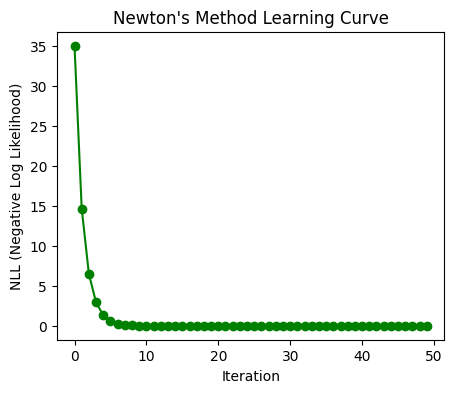

In [8]:
# 초기 파라미터 (0으로 초기화)
w = np.zeros(Phi.shape[1])
max_iter = 50
tol = 1e-6

loss_history = []

for i in range(max_iter):
    grad = gradient(w, Phi, t)
    H = hessian(w, Phi, t)
    delta = np.linalg.inv(H).dot(grad)  # H^-1 * grad
    
    w_new = w - delta
    loss = negative_log_likelihood(w_new, Phi, t)
    loss_history.append(loss)
    
    # 수렴 체크
    if np.linalg.norm(w_new - w) < tol:
        w = w_new
        print(f"Iteration {i}: Converged.")
        break
    
    w = w_new
    print(f"Iteration {i}: loss={loss:.4f}, w={w}")

print("\n학습 완료 파라미터 w =", w)
print("최종 Negative Log Likelihood =", negative_log_likelihood(w, Phi, t))

# 학습 곡선 시각화
plt.figure(figsize=(5,4))
plt.plot(loss_history, 'o-', color='green')
plt.xlabel("Iteration")
plt.ylabel("NLL (Negative Log Likelihood)")
plt.title("Newton's Method Learning Curve")
plt.show()


**[완전 분리(perfect separation) 문제]**: 위 예제처럼 (확장된) 특성 공간에서 데이터를 완벽히 분리 가능한 경우
- 로지스틱 회귀의 **최대우도해**가 $\|\mathbf{w}\|\to\infty$로 발산한다.  
- 즉, 음의 로그우도(NLL)는 0에 한없이 가까워지지만, $\mathbf{w}$는 한없이 커진다.  
- 실제로 likelihood는 계속 높아지나, 완벽 분리 때문에 무한대로 발산하는 것이다.


### 9.4 결정 경계 시각화

중간에 멈춰서 학습된 w를 사용해 p=0.5인 경계를 그려보면, 2차 다항 확장으로 인한 **비선형적인 결정경계**를 나타낼 수 있다.


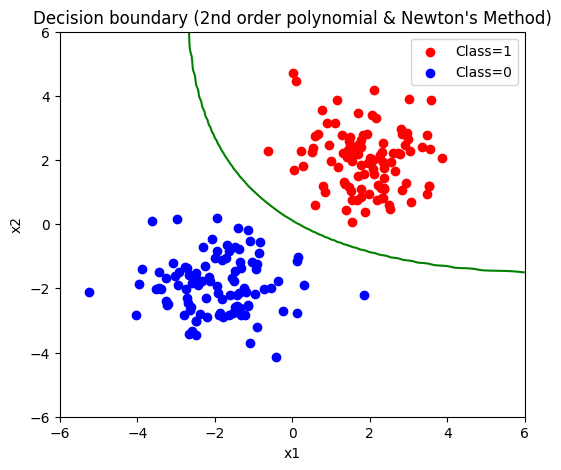

In [9]:
# (1) 2D grid 생성
x1_vals = np.linspace(-6,6,150)
x2_vals = np.linspace(-6,6,150)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
grid_points = np.c_[X1.ravel(), X2.ravel()]  # shape=(22500,2)

# (2) Phi 변환
Phi_grid = phi_polynomial_2nd(grid_points)   # shape=(22500,6)

# (3) 예측 확률
z_grid = Phi_grid.dot(w)
y_grid = sigmoid(z_grid).reshape(X1.shape)

# (4) 시각화
plt.figure(figsize=(6,5))
plt.scatter(X_class1[:,0], X_class1[:,1], c='r', label='Class=1')
plt.scatter(X_class0[:,0], X_class0[:,1], c='b', label='Class=0')

# contour로 p=0.5인 라인을 그림 => 결정경계
plt.contour(X1, X2, y_grid, levels=[0.5], colors='g')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision boundary (2nd order polynomial & Newton's Method)")
plt.legend()
plt.show()


### 9.5 결과 정리

일반적으로 뉴턴 방법을 사용할 때는,  
- 통상 **10번 전후의 반복**만으로도 **수렴**하는 경우가 많다 [2차 수렴(quadratic convergence)의 특성].  


**결론**:

1. 본 실습과 같이 분류기로만 사용하는 경우: 
   - **10~20번 정도 반복**한 후 NLL이 충분히 작아졌으면, “이미 분류를 거의 완벽히 달성했다”고 보고 중지할 수 있다.
   - 즉, 더 이상 반복해봐야 $\mathbf{w}$만 계속 커지고, 이미 분류성능은 포화상태로 유지된다.

2. 일반적인 로지스틱 회귀분석의 경우:
   - 회귀계수 값($\mathbf{w}$)의 해석이 중요한 경우 비현실적으로 크거나 작은 $\mathbf{w}$값은 문제가 될 수 있다.
   - 이러한 경우 **L2(릿지) 정규화**나 **L1(라쏘) 정규화**를 적용하면 $\mathbf{w}$가 무한정 커지지 않는 **유한한 최적해**에 도달한다.  
   - 이렇게 함으로써 **과적합(overfitting)도 방지**하고, **로지스틱 회귀 해가 발산하지 않도록** 안정적으로 모델을 학습할 수 있다.
